# Week 1 · Day 5 · Task 3 — One sentence through the whole pipeline

**From Tokens to Transformers** · Consulting & Analytics Club, IIT Guwahati

You have spent the week on the pieces. Today you push one sentence through a real, trained transformer (GPT-2) and print what every stage produces: token IDs, embeddings, attention weights, logits, and the next word.

**Time:** about 30 minutes. **What you need:** a Google account for Colab. No GPU needed; GPT-2 small runs on CPU.

**By the end you will be able to:**

1. print the token IDs a model actually sees for a sentence, and explain why there are more IDs than words
2. pull the embedding matrix out of a model and show that a token ID is just a row index into it
3. extract the attention weights of a real head and read the heatmap
4. turn the final hidden state into a probability over the next token, by hand, and match the model's own prediction

> Run every cell in order (`Shift + Enter`). Cells marked **✎ Your turn** need you to edit or write something. Do them; they are the point.

## 0 · Setup

In [1]:
!pip -q install transformers torch matplotlib

import torch, matplotlib.pyplot as plt
from transformers import GPT2TokenizerFast, GPT2LMHeadModel

tok = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager").eval()   # eager → we can read attention weights
cfg = model.config
print(f"GPT-2 small: {cfg.n_layer} layers, {cfg.n_head} heads, d_model={cfg.n_embd}, vocab={cfg.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 small: 12 layers, 12 heads, d_model=768, vocab=50257


## 1 · Stage 1: tokens

In [5]:
sentence = "I am Himani Thakur and I love to sketch 09089706"

ids = tok(sentence, return_tensors="pt")["input_ids"]          # shape (1, T)
print("words :", len(sentence.split()))
print("tokens:", ids.shape[1])
print()
for i, t in zip(ids[0].tolist(), tok.convert_ids_to_tokens(ids[0])):
    print(f"{i:>6}  {t!r}")

words : 10
tokens: 15

    40  'I'
   716  'Ġam'
 10978  'ĠHim'
  3216  'ani'
   536  'ĠTh'
   461  'ak'
   333  'ur'
   290  'Ġand'
   314  'ĠI'
  1842  'Ġlove'
   284  'Ġto'
 17548  'Ġsketch'
  7769  'Ġ09'
 49352  '089'
 35402  '706'


GPT-2 uses byte-pair encoding. The `Ġ` you see is how it marks *a space before this token* — so `ĠClub` is the token " Club". Rare words get split into pieces; common ones stay whole.

✎ **Your turn:** replace `sentence` with one containing (a) a made-up word, (b) a long number like 2026091, (c) an emoji. How many tokens does each become? Which is most expensive per character?

## 2 · Stage 2: embeddings

In [6]:
E = model.transformer.wte.weight        # the token embedding matrix, shape (vocab, d_model)
P = model.transformer.wpe.weight        # the position embedding matrix, shape (max_positions, d_model)
print("token embedding matrix :", tuple(E.shape))
print("position embedding matrix:", tuple(P.shape))

# A token ID is literally a row index. Look up the row for our first token:
first_id = ids[0, 0].item()
print(f"\ntoken {first_id} ({tok.decode([first_id])!r}) → first 8 numbers of its 768-dim vector:")
print(E[first_id, :8].detach().numpy().round(3))

# What the model actually feeds into the first block: token vector + position vector, per position
x0 = E[ids[0]] + P[torch.arange(ids.shape[1])]
print("\ninput to block 1:", tuple(x0.shape), "= (tokens, d_model)")

token embedding matrix : (50257, 768)
position embedding matrix: (1024, 768)

token 40 ('I') → first 8 numbers of its 768-dim vector:
[ 0.147 -0.096  0.143 -0.106 -0.012 -0.096 -0.217 -0.114]

input to block 1: (15, 768) = (tokens, d_model)


That is the whole of "embedding": one lookup per token, plus one lookup per position, added together. Nothing is computed yet.

✎ **Your turn:** compute the cosine similarity between the embedding rows for `" king"` and `" queen"`, and between `" king"` and `" banana"`. (`tok.encode(" king")` gives the ID; `torch.nn.functional.cosine_similarity` does the rest.) Do the numbers match your Day 2 intuition?

In [7]:

import torch.nn.functional as F
def sim(a, b):
    ia, ib = tok.encode(a)[0], tok.encode(b)[0]
    return F.cosine_similarity(E[ia], E[ib], dim=0).item()

print("king ~ queen :", round(sim(" king", " queen"), 3))
print("king ~ banana:", round(sim(" king", " banana"), 3))

king ~ queen : 0.657
king ~ banana: 0.256


## 3 · Stage 3: attention

attention tensors: 12 layers × (12, 15, 15) = (heads, T, T)


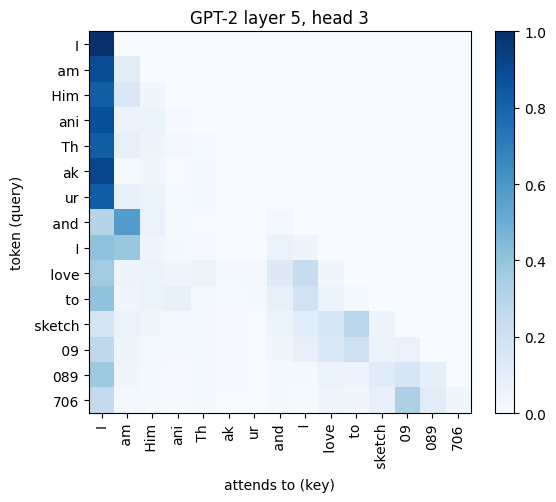

each row sums to: [1. 1. 1.] … (softmax)


In [8]:
with torch.no_grad():
    out = model(ids, output_attentions=True, output_hidden_states=True)

attn = out.attentions              # tuple of 12 tensors, each (batch, heads, T, T)
print("attention tensors:", len(attn), "layers ×", tuple(attn[0].shape[1:]), "= (heads, T, T)")

layer, head = 5, 3                 # try others!
A = attn[layer][0, head]           # (T, T): row i = how much token i attends to each token j
labels = [t.replace("Ġ", " ") for t in tok.convert_ids_to_tokens(ids[0])]

plt.figure(figsize=(6, 5))
plt.imshow(A.numpy(), cmap="Blues")
plt.xticks(range(len(labels)), labels, rotation=90); plt.yticks(range(len(labels)), labels)
plt.xlabel("attends to (key)"); plt.ylabel("token (query)")
plt.title(f"GPT-2 layer {layer}, head {head}"); plt.colorbar(); plt.tight_layout(); plt.show()

print("each row sums to:", A.sum(dim=1)[:3].numpy().round(3), "… (softmax)")

Read the heatmap: the upper triangle is empty because GPT-2 is **causal** — a token can only attend to itself and earlier tokens. Each row is a softmax, so it sums to 1.

✎ **Your turn:** loop over all 12 layers × 12 heads and find the head where `A[i, i-1]` (attention to the *previous* token) is largest on average. Print `(layer, head, score)`. You found such a head in Transformer Explainer on Wednesday; now find it in the weights.

In [9]:
best = max(
    (
        (l, h, attn[l][0, h].diagonal(offset=-1).mean().item())
        for l in range(cfg.n_layer)
        for h in range(cfg.n_head)
    ),
    key=lambda x: x[2]
)

print(
    "strongest previous-token head: "
    "layer %d, head %d, mean weight %.2f" % best
)

strongest previous-token head: layer 4, head 11, mean weight 1.00


## 4 · Stage 4: logits, and the next word

In [11]:
h_last = out.hidden_states[-1][0, -1]          # final hidden state of the LAST token, shape (d_model,)
logits_by_hand = h_last @ E.T                   # GPT-2 ties the output layer to the embedding matrix
logits_model   = out.logits[0, -1]
print("hand-computed logits match the model's:", torch.allclose(logits_by_hand, logits_model, atol=1e-3))

probs = torch.softmax(logits_model, dim=0)
top = torch.topk(probs, 8)
print(f"\nafter {sentence!r}, the model predicts next:")
for p, i in zip(top.values, top.indices):
    print(f"  {p.item():6.3f}  {tok.decode([i.item()])!r}")

hand-computed logits match the model's: True

after 'I am Himani Thakur and I love to sketch 09089706', the model predicts next:
   0.092  '.'
   0.090  '\n'
   0.025  ' ('
   0.015  ' -'
   0.013  ','
   0.012  '<|endoftext|>'
   0.011  ' |'
   0.008  ' ['


That is the whole forward pass, and you have now touched every tensor in it:

```
text ──tokenizer──▶ ids ──lookup──▶ embeddings ──12 blocks of attention+MLP──▶ hidden state ──× Eᵀ──▶ logits ──softmax──▶ P(next token)
```

Generation is just: pick a token from that distribution, append it, run again. Week 2 is about how you pick.

✎ **Your turn:** write a 6-line loop that generates 15 tokens greedily (always the argmax) and prints the sentence. Then change `argmax` to sampling with `torch.multinomial(probs, 1)` and run it three times. What changed, and why does this matter for Week 2?

In [12]:
cur = ids.clone()
for _ in range(15):
    with torch.no_grad():
        nxt = model(cur).logits[0, -1].argmax()          # greedy
    cur = torch.cat([cur, nxt.view(1, 1)], dim=1)
print(tok.decode(cur[0]))

I am Himani Thakur and I love to sketch 09089706.

I am Himani Thakur and I love to sketch


## 5 · Before the weekend

Assignment 1 is a 15-question quiz on tokenization and attention. Everything it asks is something you printed today: what a token ID is, what the embedding matrix does, why the attention heatmap is triangular, how logits become a prediction. Re-run any cell you are unsure about before you take it.

`File → Save a copy in Drive` before you close.

---
*From Tokens to Transformers, 2026. Runs on the free Colab tier.*